In [1]:
%matplotlib widget

import os
import numpy as np
import pandas as pd
import ipywidgets as W
import matplotlib.pyplot as plt
from GCRsim_v02f import CosmicRaySimulation
from typing import Tuple, Optional, Union
from IPython.display import display
from dataclasses import dataclass

In [2]:
def energy_deposition_stats(
    df: pd.DataFrame,
    pid_col: str = "PID",
    x_col: str = "x", # microns in energy deposition data
    y_col: str = "y") -> pd.DataFrame:
    """
    Group by parent PID (via CosmicRaySimulation.get_parent_pid) and return:
      - avg_x, avg_y  (means in microns)
      - count (total number of energy depositions, including from delta rays)
      - mean_x_px, mean_y_px (means converted to pixels)
      - std_x_px, std_y_px   (per-parent std dev in pixels, from CSV hits)
      - sigma_r_csv          (geometric mean of std_x_px and std_y_px)

    Parameters
    ----------
    df : DataFrame with columns pid_col, x_col, y_col.
          x_col, y_col are in microns.

    Returns
    -------
    DataFrame indexed by parent_pid with added pixel-space stats and sigma_r_ed.
    """
    microns_per_pixel = 10.0
    
    cols = [pid_col, x_col, y_col]
    dfw = df[cols].copy()

    # Parent PID
    dfw["parent_pid"] = dfw[pid_col].map(CosmicRaySimulation.get_parent_pid).astype(np.int64)

    g = dfw.groupby("parent_pid", sort=False, observed=True)

    # means and stds in µm, then convert to px 
    agg = g.agg(
        mean_x_um=(x_col, "mean"),
        mean_y_um=(y_col, "mean"),
        std_x_um=(x_col, "std"),   # sample std ddof=1
        std_y_um=(y_col, "std"),
        count=(x_col, "size"),
    )
    # Convert to pixels
    agg["mean_x_px"] = agg["mean_x_um"] / microns_per_pixel
    agg["mean_y_px"] = agg["mean_y_um"] / microns_per_pixel
    agg["std_x_px"]  = agg["std_x_um"] / microns_per_pixel
    agg["std_y_px"]  = agg["std_y_um"] / microns_per_pixel

    # Scalar proxy for spread (pixels)
    agg["sigma_r_ed"] = np.sqrt(agg["std_x_px"] * agg["std_y_px"])

    agg = agg.reset_index()
    agg["pid_label"] = agg["parent_pid"].map(CosmicRaySimulation.decode_pid)
    agg = agg.set_index("parent_pid")

    # column order
    col_order = [
        "mean_x_um", "mean_y_um", # µm
        "mean_x_px", "mean_y_px", # px
        "std_x_um", "std_y_um", # µm (for reference)
        "std_x_px", "std_y_px", # px
        "sigma_r_ed",  # px
        "count", "pid_label"
    ]

    # Keep only existing columns, in order
    col_order = [c for c in col_order if c in agg.columns]
    return agg[col_order]

In [3]:
raw_df = pd.read_csv("./Outputs/validation tests/energyDepositions_d2020_352_run1.csv")

stats_df = energy_deposition_stats(raw_df)

print(stats_df.head())

               mean_x_um     mean_y_um    mean_x_px    mean_y_px  std_x_um  \
parent_pid                                                                   
16384       17467.704894  18096.205967  1746.770489  1809.620597  1.318560   
33570816    32861.101047  23777.641286  3286.110105  2377.764129  0.700168   
33587200    37302.169744  11187.763549  3730.216974  1118.776355  1.073046   
33603584    11960.786093   7562.050408  1196.078609   756.205041  0.495597   
33685504    30868.297725  11496.792536  3086.829773  1149.679254  6.906489   

            std_y_um  std_x_px  std_y_px  sigma_r_ed  count       pid_label  
parent_pid                                                                   
16384       2.179724  0.131856  0.217972    0.169532    101  e-P0001-D00000  
33570816    2.051489  0.070017  0.205149    0.119849   2750  H-P0001-D00000  
33587200    1.322238  0.107305  0.132224    0.119114   2056  H-P0002-D00000  
33603584    1.185296  0.049560  0.118530    0.076644    392  H-

In [ ]:
#  patch viewer
ArrayLike = Union[np.ndarray, np.memmap]

@dataclass
class MomentParams:
    half_size: int = 32
    min_pixels: int = 3
    max_pixels: int = 200_000
    seed_on_round: bool = True
    positive_threshold: float = 0.0  # pixels > threshold are signal

def _extract_patch(img: ArrayLike, x: int, y: int, half: int) -> Tuple[np.ndarray, Tuple[int,int]]:
    H, W = img.shape
    x0 = max(0, x - half); y0 = max(0, y - half)
    x1 = min(W, x + half + 1); y1 = min(H, y + half + 1)
    return img[y0:y1, x0:x1], (x0, y0)

def _flood_fill(mask: np.ndarray, seed_xy: Tuple[int,int]) -> np.ndarray:
    H, W = mask.shape
    sx, sy = seed_xy
    if not (0 <= sx < W and 0 <= sy < H) or not mask[sy, sx]:
        return np.zeros_like(mask, dtype=bool)
    out = np.zeros_like(mask, dtype=bool)
    stack = [(sx, sy)]
    out[sy, sx] = True
    nbrs = [(-1,-1),(0,-1),(1,-1),(-1,0),(1,0),(-1,1),(0,1),(1,1)]
    while stack:
        x, y = stack.pop()
        for dx, dy in nbrs:
            nx, ny = x+dx, y+dy
            if 0 <= nx < W and 0 <= ny < H and (not out[ny, nx]) and mask[ny, nx]:
                out[ny, nx] = True
                stack.append((nx, ny))
    return out

def create_floodfill_viewer(
    img: ArrayLike,
    parent_df: pd.DataFrame,
    *,
    x_seed_col: str = "avg_x (microns)",
    y_seed_col: str = "avg_y (microns)",
    label_col: Optional[str] = "pid_label",   
    params: MomentParams = MomentParams(), microns_per_pixel: float = 10.0
):
    """
    Interactive viewer for verifying flood-fill windows.
    Requirements on parent_df:
      - index: parent_pid (ints)
      - columns: x_seed_col, y_seed_col (floats)
        already computed image-based centroids to display.
      - label_col (e.g., 'pid_label') for nicer dropdown text.
    """

    # Build dropdown choices
    def _choice_for_pid(pid):
        if label_col and label_col in parent_df.columns:
            return f"{pid} | {parent_df.loc[pid, label_col]}"
        return str(pid)

    parent_pids = parent_df.index.to_list()
    choices = { _choice_for_pid(pid): pid for pid in parent_pids }

    dd = W.Dropdown(options=choices, description="Event:", layout=W.Layout(width="60%"))
    half_slider = W.IntSlider(params.half_size, 16, 256, 1, description="Half-size")
    thr_box = W.FloatText(value=params.positive_threshold, description="> DN")
    show_seed = W.Checkbox(True, description="Show seed (avg_x,avg_y)")
    stretch = W.FloatSlider(value=1.0, min=0.2, max=5.0, step=0.1, description="Contrast")
    info = W.HTML("")

    controls = W.HBox([dd, half_slider, thr_box, show_seed, stretch])

    out = W.Output()
    decoder = CosmicRaySimulation(grid_size=2)
    def _plot(_=None):
        with out:
            out.clear_output()
            pid = dd.value
            half = int(half_slider.value)
            thr = float(thr_box.value)

            # Seed (global)
            sx_f = float(parent_df.loc[pid, x_seed_col]) / microns_per_pixel
            sy_f = float(parent_df.loc[pid, y_seed_col]) / microns_per_pixel
            sx = int(round(sx_f)) if params.seed_on_round else int(np.floor(sx_f))
            sy = int(round(sy_f)) if params.seed_on_round else int(np.floor(sy_f))

            # Window + mask + flood-fill
            patch, (x0, y0) = _extract_patch(img, sx, sy, half)
            seed_local = (sx - x0, sy - y0)
            mask = patch > thr
            comp = _flood_fill(mask, seed_local)
            n_pix = int(comp.sum())

            Ht, Wd = patch.shape
            extent = (x0, x0+Wd, y0+Ht, y0)  # so imshow aligns with global coords (origin top-left)

            fig = plt.figure(figsize=(8, 6))
            ax = fig.add_subplot(111)
            ax.imshow(patch, cmap="gray", origin="upper", extent=extent, interpolation="nearest")

            # Overlay flood-filled pixels (semi-transparent)
            comp_alpha = np.zeros((*comp.shape, 4), dtype=float)
            comp_alpha[comp] = [1, 0, 0, 0.25]  # red with alpha
            ax.imshow(comp_alpha, origin="upper", extent=extent, interpolation="nearest")

            # Red boundary via contour
            if comp.any():
                # contour expects 2D scalar field; use comp.astype(int)
                # draw at 0.5 to get the edge between 0 and 1
                ax.contour(comp.astype(int), levels=[0.5], colors="red", linewidths=1.5,
                           origin="upper", extent=extent)

            # Seed marker
            if show_seed.value:
                ax.plot([sx],[sy], marker="x", ms=10, mew=2, color="yellow", label="seed")

            ax.set_title(f"parent_pid={decoder.decode_pid(pid)} | window [{x0}:{x0+Wd}, {y0}:{y0+Ht}] | flood pix={n_pix}")
            ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)")
            ax.legend(loc="lower right")
            ax.set_aspect("equal")
            plt.show()

            info.value = f"<code>Seed=({sx},{sy})</code> &nbsp; <code>Half={half}</code> &nbsp; <code>thr&gt;{thr}</code> &nbsp; <code>flood_pix={n_pix}</code>"

    # Wire up interactions
    for w in (dd, half_slider, thr_box, show_seed, stretch):
        w.observe(_plot, names="value")
    _plot()  # initial draw

    display(controls, out, info)


In [5]:
# img: 4096x4096 DN frame (numpy array or memmap)
# stats_df: output of energy_deposition_stats(...)
img = np.load("./Outputs/validation tests/DNmap_d2020_352_run1.npy")
# Example (using pid_label if present):
create_floodfill_viewer(img, stats_df, x_seed_col="mean_x_um", y_seed_col="mean_y_um",
                        label_col="pid_label",
                        params=MomentParams(half_size=32,positive_threshold=0.0))


Output()

HTML(value='<code>Seed=(1747,1810)</code> &nbsp; <code>Half=32</code> &nbsp; <code>thr&gt;0.0</code> &nbsp; <c…

In [ ]:
def image_moments(patch: np.ndarray, mask: np.ndarray) -> Optional[dict]:
    """Compute sum, centroid, covariance, principal axes, orientation."""
    ys, xs = np.nonzero(mask)
    if xs.size == 0:
        return None
    w = patch[ys, xs].astype(np.float64)
    M00 = w.sum()
    if M00 <= 0:
        return None

    x = xs.astype(np.float64)
    y = ys.astype(np.float64)

    M10 = np.dot(x, w); M01 = np.dot(y, w)
    xbar = M10 / M00;   ybar = M01 / M00

    dx = x - xbar; dy = y - ybar
    M20c = np.dot(dx*dx, w)
    M02c = np.dot(dy*dy, w)
    M11c = np.dot(dx*dy, w)

    cov_xx = M20c / M00
    cov_yy = M02c / M00
    cov_xy = M11c / M00

    tr = cov_xx + cov_yy
    det = max(cov_xx*cov_yy - cov_xy*cov_xy, 0.0)
    disc = max(tr*tr/4 - det, 0.0)
    lam1 = max(tr/2 + np.sqrt(disc), 0.0)  # major
    lam2 = max(tr/2 - np.sqrt(disc), 0.0)  # minor
    sigma_major = np.sqrt(lam1)
    sigma_minor = np.sqrt(lam2)
    theta = 0.5 * np.arctan2(2*cov_xy, (cov_xx - cov_yy))

    return dict(
        M00=M00,
        xbar_local=xbar, ybar_local=ybar,
        cov_xx=cov_xx, cov_yy=cov_yy, cov_xy=cov_xy,
        sigma_major=sigma_major, sigma_minor=sigma_minor, theta=theta,
        n_pix=int(xs.size),
    )

def augment_with_image_moments(
    img: ArrayLike,
    parent_df: pd.DataFrame,
    x_seed_col: str = "mean_x_um",  # energy deposition data in µm
    y_seed_col: str = "mean_y_um", 
    params: MomentParams = MomentParams(),
    microns_per_pixel: float = 10.0
) -> pd.DataFrame:
    """
    Zero-background fast path:
      - mask = (DN > positive_threshold)
      - flood-fill component containing the seed (seed from CSV, in µm)
      - compute M00, centroid, covariance, principal axes, orientation (in pixels)
    Returns parent_df + new columns, indexed by parent_pid.
    """
    out_cols = [
        "flux_M00","xbar","ybar",
        "cov_xx","cov_yy","cov_xy",
        "sigma_major","sigma_minor","theta_rad",
        "n_pix","win_x0","win_y0","status"
    ]
    rows = []

    H, W = img.shape

    for parent_pid, row in parent_df.iterrows():
        # Convert seed from µm -> px
        sx_f = float(row[x_seed_col]) / microns_per_pixel
        sy_f = float(row[y_seed_col]) / microns_per_pixel
        sx = int(round(sx_f)) if params.seed_on_round else int(np.floor(sx_f))
        sy = int(round(sy_f)) if params.seed_on_round else int(np.floor(sy_f))

        # Extract window
        patch, (x0, y0) = _extract_patch(img, sx, sy, params.half_size)
        seed_local = (sx - x0, sy - y0)

        # Zero-background mask + flood-fill
        prelim = patch > params.positive_threshold
        comp = _flood_fill(prelim, seed_local)

        n_pix = int(comp.sum())
        if n_pix < params.min_pixels or n_pix > params.max_pixels:
            rows.append((parent_pid, dict(
                flux_M00=np.nan, xbar=np.nan, ybar=np.nan,
                cov_xx=np.nan, cov_yy=np.nan, cov_xy=np.nan,
                sigma_major=np.nan, sigma_minor=np.nan, theta_rad=np.nan,
                n_pix=n_pix, win_x0=x0, win_y0=y0, status="rejected_npix"
            )))
            continue

        stats = image_moments(patch, comp)
        if stats is None:
            rows.append((parent_pid, dict(
                flux_M00=np.nan, xbar=np.nan, ybar=np.nan,
                cov_xx=np.nan, cov_yy=np.nan, cov_xy=np.nan,
                sigma_major=np.nan, sigma_minor=np.nan, theta_rad=np.nan,
                n_pix=n_pix, win_x0=x0, win_y0=y0, status="no_stats"
            )))
            continue

        # Convert centroid to global pixel coords
        xbar_global = x0 + stats["xbar_local"] 
        ybar_global = y0 + stats["ybar_local"] 

        rec = dict(
            flux_M00=stats["M00"],
            xbar=xbar_global, ybar=ybar_global,      # pixels
            cov_xx=stats["cov_xx"], cov_yy=stats["cov_yy"], cov_xy=stats["cov_xy"],  # px^2
            sigma_major=stats["sigma_major"],       # pixels
            sigma_minor=stats["sigma_minor"],       # pixels
            theta_rad=stats["theta"],
            n_pix=stats["n_pix"], win_x0=x0, win_y0=y0, status="ok"
        )

        rows.append((parent_pid, rec))

    aug = parent_df.copy()
    add = pd.DataFrame.from_dict(dict(rows), orient="index")[out_cols]
    add.index.name = parent_df.index.name or "parent_pid"
    return aug.join(add, how="left")


def process_seeded_blobs(
    img: ArrayLike,
    hits_csv: str,
    out_csv: str,
    win: MomentParams = MomentParams(),
    use_pid_grouping: bool = True
):
    """
    Stream over parent groups derived from CSV x,y (in microns).
    For each, extract a window (in pixels), flood-fill >0 DN, compute moments, and append to out_csv.
    CSV must contain: parent_pid, x, y  (x,y in µm)
    """
    microns_per_pixel= 10.0,
    df = pd.read_csv(hits_csv)

    if use_pid_grouping:
        seeds = (df.groupby("parent_pid")[["x","y"]].mean().reset_index())
    else:
        seeds = df[["parent_pid","x","y"]].drop_duplicates()

    cols = ["parent_pid","flux","x_px","y_px","xbar_px","ybar_px",
            "sigma_major_px","sigma_minor_px","theta_rad","n_pix","x0","y0"]
    header_needed = not os.path.exists(out_csv)
    out_f = open(out_csv, "a", buffering=1)
    if header_needed:
        out_f.write(",".join(cols) + "\n")

    H, W = img.shape
    for _, row in seeds.iterrows():
        # µm -> pixels for seed
        px_um, py_um = float(row["x"]), float(row["y"])
        px = int(round(px_um / microns_per_pixel))
        py = int(round(py_um / microns_per_pixel))

        if not (0 <= px < W and 0 <= py < H):
            continue

        patch, (x0, y0) = _extract_patch(img, px, py, win.half_size)

        prelim = patch > 0.0
        sx, sy = px - x0, py - y0
        comp = _flood_fill(prelim, (sx, sy))

        n_pix = int(comp.sum())
        if n_pix < win.min_pixels or n_pix > win.max_pixels:
            continue

        stats = image_moments(patch, comp)
        if stats is None:
            continue

        xbar = x0 + stats["xbar_local"]
        ybar = y0 + stats["ybar_local"]

        line = [
            str(row["parent_pid"]),
            f"{stats['M00']:.6g}",
            str(px), str(py),
            f"{xbar:.6f}", f"{ybar:.6f}",
            f"{stats['sigma_major']:.6f}", f"{stats['sigma_minor']:.6f}",
            f"{stats['theta']:.6f}",
            str(n_pix), str(x0), str(y0)
        ]
        out_f.write(",".join(line) + "\n")

    out_f.close()


In [13]:
params = MomentParams(half_size=32, positive_threshold=0.0)
aug_df = augment_with_image_moments(img, stats_df, params=params)

# One-number diffusion proxy (pixels)
aug_df["sigma_r_dn"] = np.sqrt(aug_df["sigma_major"] * aug_df["sigma_minor"])
aug_df = aug_df[['pid_label'] + [x for x in aug_df.columns if x != 'pid_label']]
  
aug_df["Var_DN"] = aug_df["sigma_r_dn"]**2  
aug_df["Var_ED"] = aug_df["sigma_r_ed"]**2
aug_df["Var_TH"] = (1/12)
aug_df["Var_CD_derived"] = aug_df["Var_DN"] - aug_df["Var_ED"] - aug_df["Var_TH"]
aug_df["Var_CD_expected"] = (0.314)**2
aug_df["Error"] = ((aug_df["Var_CD_expected"] - aug_df["Var_CD_derived"])/aug_df["Var_CD_expected"])

aug_df.to_csv("d2020_f352_run1_parent_moments_report.csv", index=False)

aug_df.head()


,pid_label,mean_x_um,mean_y_um,mean_x_px,mean_y_px,std_x_um,std_y_um,std_x_px,std_y_px,sigma_r_ed,...,win_x0,win_y0,status,sigma_r_dn,Var_DN,Var_ED,Var_TH,Var_CD_derived,Var_CD_expected,Error
parent_pid,,,,,,,,,,,,,,,,,,,,,
16384,e-P0001-D00000,17467.704894,18096.205967,1746.770489,1809.620597,1.318560,2.179724,0.131856,0.217972,0.169532,...,1715,1778,ok,0.417528,0.174330,0.028741,0.083333,0.062255,0.098596,0.368582
33570816,H-P0001-D00000,32861.101047,23777.641286,3286.110105,2377.764129,0.700168,2.051489,0.070017,0.205149,0.119849,...,3254,2346,ok,0.468737,0.219714,0.014364,0.083333,0.122017,0.098596,-0.237545
33587200,H-P0002-D00000,37302.169744,11187.763549,3730.216974,1118.776355,1.073046,1.322238,0.107305,0.132224,0.119114,...,3698,1087,ok,0.439212,0.192907,0.014188,0.083333,0.095386,0.098596,0.032558
33603584,H-P0003-D00000,11960.786093,7562.050408,1196.078609,756.205041,0.495597,1.185296,0.049560,0.118530,0.076644,...,1164,724,ok,0.482522,0.232827,0.005874,0.083333,0.143619,0.098596,-0.456645
33685504,H-P0008-D00000,30868.297725,11496.792536,3086.829773,1149.679254,6.906489,1.950538,0.690649,0.195054,0.367034,...,3055,1118,ok,0.593506,0.352250,0.134714,0.083333,0.134202,0.098596,-0.361135


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


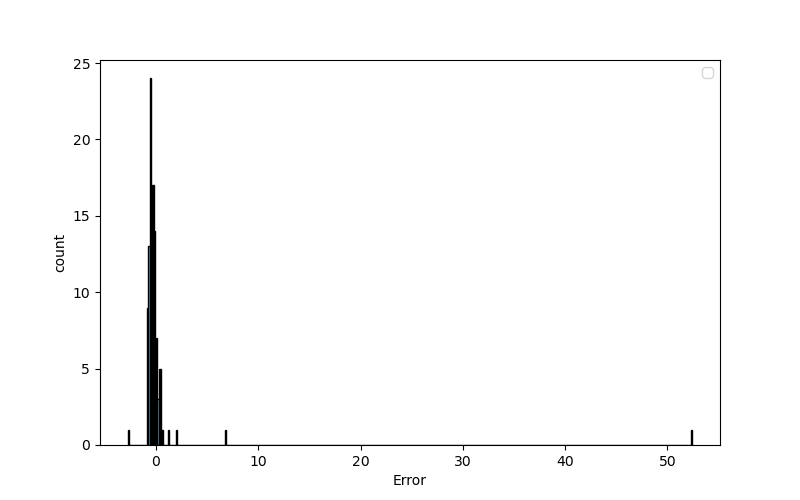

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(aug_df["Error"], bins=500, color="skyblue", edgecolor="k")
plt.xlabel("Error")
plt.ylabel("count")
plt.legend()
plt.show()